# TODO:
### 1. Import Libraries (pandas, pyodbc, seaborn, matplotlib).
### 2. Establish SQL Server Connection (Linking to the Gold Layer).
### 3. Data Ingestion: Load SQL Views into Pandas DataFrames.
### 4. Data Quality Check: Quick audit for any remaining nulls or inconsistencies.
### 5. Descriptive Statistics: Summary of trip durations and user behavior.
### 6. Advanced Visualization:
####    - [A] User Distribution (Member vs Casual).
####    - [B] Seasonality Trends (Month-over-Month).
####    - [C] Weekly Patterns (Weekday vs Weekend).
####    - [D] Hourly Rush Hour Analysis.
####    - [E] Bike Preference Analysis.
### 7. Correlation & Insights: Identifying the "Why" behind the differences.
### 8. Export Cleaned Aggregates: For Power BI Final Dashboard.

In [2]:
%pip install pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [4]:
%pip install sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sqlalchemy import create_engine


In [6]:
'''
Encoutered a MemoryError when loading 5.5M+ rows; resolved by using 'SQL Aggregation' to process data on the server, ensuring efficient memory usage and faster analysis.

'''
server = r'MALOOK\MSSQLSERVER01'  
database = 'CyclisticProject' 
driver = 'ODBC Driver 18 for SQL Server' 


connection_string = f'mssql+pyodbc://{server}/{database}?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes'
engine = create_engine(connection_string)


def run_query(query):
    return pd.read_sql(query, engine)





In [7]:
from IPython.core.display_functions import display
# Data views ingestion
df_proportions = run_query('select * from v_User_Proportions')
display(df_proportions)

,member_percentage,casual_percentage
0,64.471872,35.528128


In [8]:
df_metrics = run_query('SELECT * FROM v_Trip_Duration_Metrics') 
display(df_metrics)

,member_casual,avg_ride_length,max_ride_length,min_ride_length,median_ride_length
0,Member,12.566136,1499.966666,1.0,8.733333
1,Casual,23.505880,1574.900000,1.0,11.916666


In [9]:
df_monthly = run_query('''SELECT * FROM v_Monthly_Trends
ORDER BY CASE month_name
    WHEN 'January' THEN 1
    WHEN 'February' THEN 2
    WHEN 'March' THEN 3
    WHEN 'April' THEN 4
    WHEN 'May' THEN 5
    WHEN 'June' THEN 6
    WHEN 'July' THEN 7
    WHEN 'August' THEN 8
    WHEN 'September' THEN 9
    WHEN 'October' THEN 10
    WHEN 'November' THEN 11
    WHEN 'December' THEN 12
END;''')
display(df_monthly)

,month_name,member_casual,total_rides_per_month
0,January,Member,112362
1,January,Casual,23453
2,February,Member,122130
3,February,Casual,27052
4,March,Casual,83074
5,March,Member,208511
6,April,Casual,105540
7,April,Member,257973
8,May,Member,314113
9,May,Casual,176175


In [10]:
df_weekly = run_query('select * from v_Weekly_Trends')
display(df_weekly)

,day_name,member_casual,total_rides_per_day
0,Tuesday,Member,552667
1,Wednesday,Member,540373
2,Tuesday,Casual,217346
3,Monday,Member,493487
4,Sunday,Member,374681
5,Sunday,Casual,317879
6,Wednesday,Casual,213212
7,Thursday,Casual,248446
8,Friday,Member,518734
9,Thursday,Member,565359


In [11]:
df_hourly = run_query("SELECT * FROM v_Hourly_Trends order by ride_hour")
display(df_hourly)

,ride_hour,member_casual,total_rides
0,0,Casual,36928
1,0,Member,31418
2,1,Member,19119
3,1,Casual,23602
4,2,Casual,15755
5,2,Member,11437
6,3,Member,7528
7,3,Casual,8765
8,4,Member,8610
9,4,Casual,6965


In [12]:
df_bikes = run_query("SELECT * FROM v_Bike_Preferences")
display(df_bikes)

,rideable_type,member_casual,number_of_bike_users
0,Electric bike,Member,2210006
1,Electric bike,Casual,1248004
2,Classic bike,Casual,672653
3,Classic bike,Member,1275355


In [13]:
df_stations = run_query('SELECT * FROM v_Top_Stations_Detailed')
display(df_stations)

,Station_Type,User_Type,Station_Name,Total_Rides
0,Start,Casual,Dusable lake shore dr & monroe st,30798
1,Start,Casual,Navy pier,27098
2,Start,Casual,Streeter dr & grand ave,23368
3,Start,Casual,Michigan ave & oak st,22125
4,Start,Casual,Dusable lake shore dr & north blvd,19073
5,Start,Casual,Millennium park,18823
6,Start,Casual,Shedd aquarium,16553
7,Start,Casual,Theater on the lake,15491
8,Start,Casual,Dusable harbor,15447
9,Start,Casual,Michigan ave & 8th st,11058


In [14]:
#  Data Quality Check: Quick audit for any remaining nulls or inconsistencies.

print("1. Null Values Check:")
print(f"- Monthly Trends Nulls: {df_monthly.isnull().sum().sum()}")
print(f"- Hourly Trends Nulls: {df_hourly.isnull().sum().sum()}")
print(f"- Duration Metrics Nulls: {df_metrics.isnull().sum().sum()}")
print("-" * 30)

print("2. Consistency Check:")
print(f"- Unique Months found: {df_monthly['month_name'].nunique()} (Expected: 12)")
print(f"- Unique Days found: {df_weekly['day_name'].nunique()} (Expected: 7)")
print("-" * 30)

print("3. Trip Duration Statistics (Summary):")
display(df_metrics[['member_casual', 'avg_ride_length', 'median_ride_length']])

1. Null Values Check:
- Monthly Trends Nulls: 0
- Hourly Trends Nulls: 0
- Duration Metrics Nulls: 0
------------------------------
2. Consistency Check:
- Unique Months found: 12 (Expected: 12)
- Unique Days found: 7 (Expected: 7)
------------------------------
3. Trip Duration Statistics (Summary):


,member_casual,avg_ride_length,median_ride_length
0,Member,12.566136,8.733333
1,Casual,23.505880,11.916666


In [ ]:
# 5. Descriptive Statistics: Summary of trip durations and user behavior.


print("1. Trip Duration Breakdown (Minutes):")
display(df_metrics[['member_casual', 'avg_ride_length', 'median_ride_length']])


print("\n2. Bike Type Preference:")
bike_summary = df_bikes.groupby(['member_casual', 'rideable_type'])['number_of_bike_users'].sum().unstack()
display(bike_summary)


print("\n3. Quick Insight:")
for index, row in df_metrics.iterrows():
    diff = row['avg_ride_length'] - row['median_ride_length']
    print(f"- For {row['member_casual']} riders, the gap between Average and Median is {diff:.2f} mins.")
    '''
    "Casual Riders: Longer trip durations (2x) and high electric bike usage point toward recreational behavior.

     Annual Members: Shorter, consistent trip patterns indicate a functional utility for daily commuting."
    '''
  

1. Trip Duration Breakdown (Minutes):


,member_casual,avg_ride_length,median_ride_length
0,Casual,23.505880,11.916666
1,Member,12.566136,8.733333



2. Bike Type Preference:


rideable_type,Classic bike,Electric bike
member_casual,,
Casual,672653,1248004
Member,1275355,2210006



3. Quick Insight:
- For Casual riders, the gap between Average and Median is 11.59 mins.
- For Member riders, the gap between Average and Median is 3.83 mins.


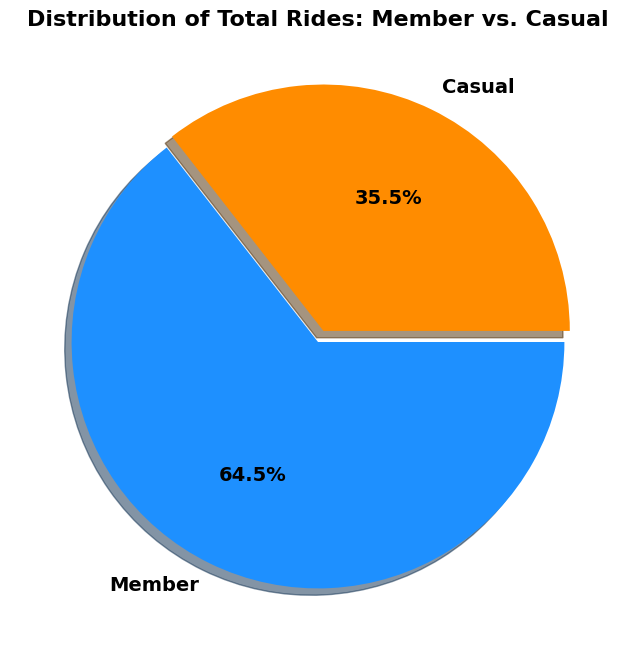

In [ ]:

# ----------------------------------------------------------------------------
# 6. [A] User Distribution (Member vs Casual)
# ----------------------------------------------------------------------------

user_counts = df_bikes.groupby('member_casual')['number_of_bike_users'].sum()

plt.figure(figsize=(8, 8))
colors = ['#FF8C00', '#1E90FF'] 
explode = (0.05, 0) 
plt.pie(user_counts, 
        labels=user_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode,
        shadow=True,
        textprops={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Distribution of Total Rides: Member vs. Casual', fontsize=16, fontweight='bold')
plt.show()

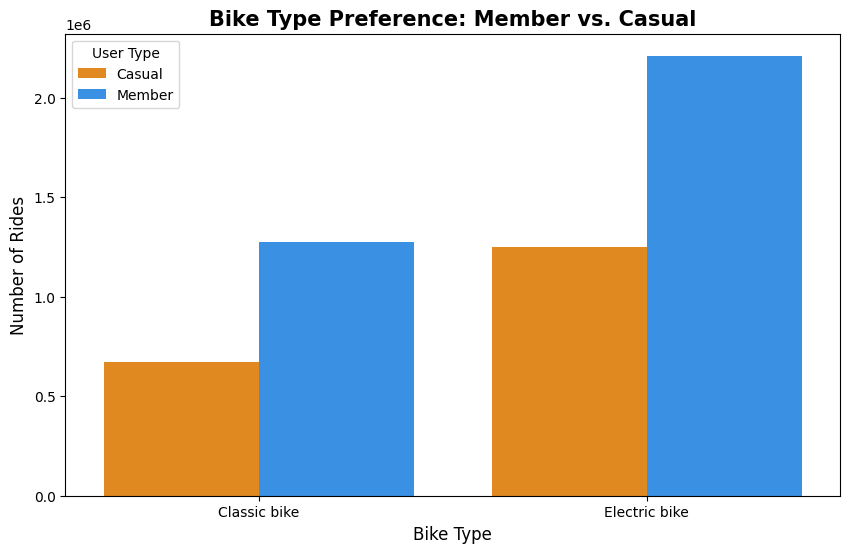

In [ ]:
# ----------------------------------------------------------------------------
# 6. [B] Bike Type Preference by User Type
# ----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(x='rideable_type', y='number_of_bike_users', hue='member_casual', 
            data=df_bikes, palette=['#FF8C00', '#1E90FF'])

plt.title('Bike Type Preference: Member vs. Casual', fontsize=15, fontweight='bold')
plt.xlabel('Bike Type', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='User Type')

plt.show()

'''
1. The Dominance of Electric Bikes
"Electric bikes are the primary driver of usage for both groups. For Casual riders, the strong preference for electric models reinforces the 'leisure' hypothesis, as they prioritize ease of use and comfort for longer trips. For Members, the high volume of electric bike trips suggests they are valued for efficiency and speed during daily commutes."

2. The Classic Bike Segment
"While electric bikes lead in popularity, Annual Members show a significantly higher retention of Classic bikes compared to Casual riders. This suggests that members may integrate bike-sharing into their fitness routines or rely on Classic bikes when they are more readily available at high-traffic commuting hubs."
'''
'''
1. Marketing Strategy
"Conversion Campaign: Focus on Electric Bike Benefits"
"To convert Casual riders into Annual members, marketing efforts should highlight discounted or priority access to electric bikes. Since the data shows Casual riders have a clear preference for electric models, leveraging this 'hook' is the most effective way to incentivize membership sign-ups."

2. Operational Strategy
"Operational Efficiency: Battery Management & Availability"
"Operations should prioritize battery maintenance and 100% charging cycles for electric bikes in two key zones: tourist/recreational areas (to cater to Casual riders) and business districts (to serve Members during peak hours). Ensuring high availability in these high-demand locations will maximize user satisfaction and system reliability."
'''

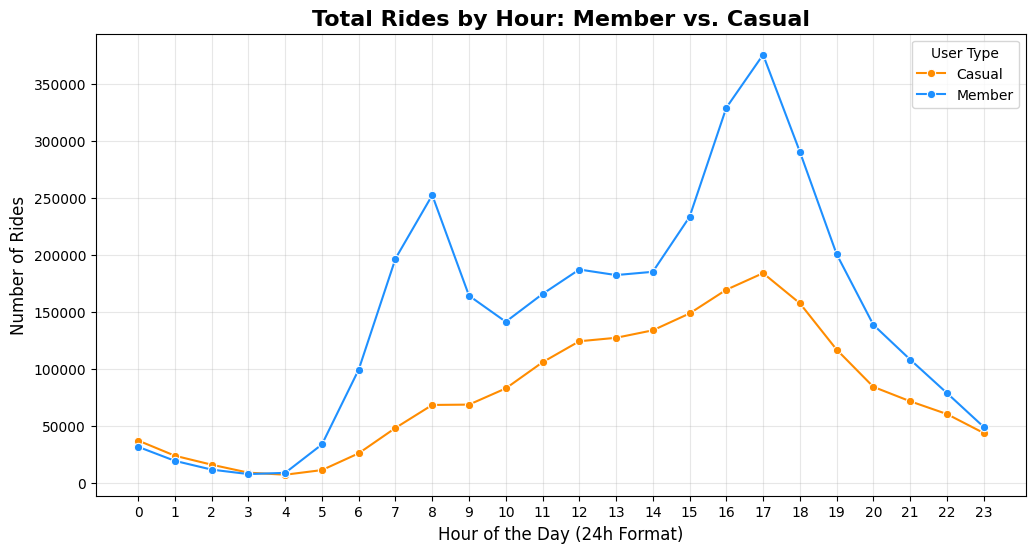

In [ ]:
# ----------------------------------------------------------------------------
# 6. [C] Hourly Trends: When do they ride?
# ----------------------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(x='ride_hour', y='total_rides', hue='member_casual', 
             data=df_hourly, marker='o', palette=['#FF8C00', '#1E90FF'])

plt.title('Total Rides by Hour: Member vs. Casual', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (24h Format)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)

plt.xticks(range(0, 24)) 
plt.grid(True, alpha=0.3)
plt.legend(title='User Type')

plt.show()

'''
Insights (Critical Findings):
1. Peak Hour Patterns
"The data reveals a distinct bimodal distribution for Annual Members, with clear peaks at 8 AM and 5 PM, perfectly aligning with typical commuting hours. In contrast, Casual riders show a gradual increase in activity throughout the day, peaking only in the late afternoon, which characterizes a recreational usage pattern."

2. Business Recommendation (Marketing Timing)
"Strategic marketing interventions to convert Casual riders should be timed during their peak engagement window (between 2 PM and 6 PM). Promotional notifications about the benefits of membership for 'daily rides' would be most effective when these users are already active on the platform."
'''


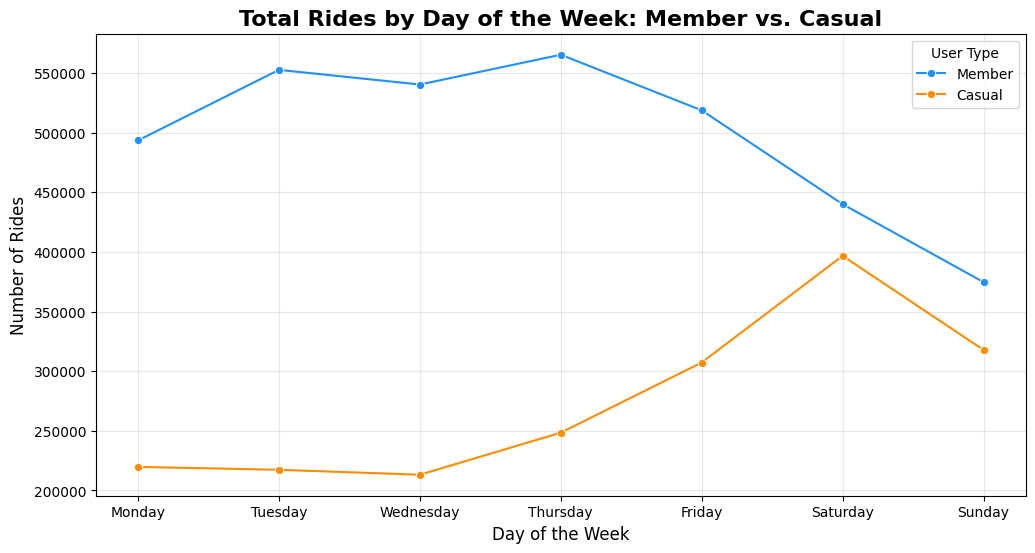

In [ ]:
# ----------------------------------------------------------------------------
# 6. [D] Weekly Trends: Weekdays vs. Weekends
# ----------------------------------------------------------------------------

df_weekly.columns = df_weekly.columns.str.strip()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

x_col = 'day_name' if 'day_name' in df_weekly.columns else 'ride_day'
y_col = 'total_rides_per_day' if 'total_rides_per_day' in df_weekly.columns else 'number_of_bike_users'

df_weekly[x_col] = pd.Categorical(df_weekly[x_col], categories=day_order, ordered=True)
df_weekly = df_weekly.sort_values(x_col)

plt.figure(figsize=(12, 6))
sns.lineplot(x=x_col, y=y_col, hue='member_casual', 
             data=df_weekly, marker='o', palette=['#1E90FF', '#FF8C00'])

plt.title('Total Rides by Day of the Week: Member vs. Casual', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='User Type')

plt.show()
'''
1. Strategic Weekly Usage

"The weekly trend analysis confirms a inverse relationship between user types: Annual Members peak during weekdays (Monday–Thursday) as part of their professional commute, while Casual riders reach their maximum activity on weekends (Saturday–Sunday), highlighting a recreational usage pattern."

2. Targeted Conversion Opportunity

"The significant spike in Casual ridership on Saturdays presents a prime opportunity for on-ground marketing. Introducing 'Weekend-to-Member' trial passes or weekend-specific membership benefits could effectively convert these high-volume recreational users into long-term subscribers."

'''

In [42]:
display(df_weekly)

,day_name,member_casual,total_rides_per_day
0,Sunday,Member,374681
1,Sunday,Casual,317879
2,Wednesday,Casual,213212
3,Tuesday,Member,552667
4,Wednesday,Member,540373
5,Tuesday,Casual,217346
6,Monday,Member,493487
7,Thursday,Casual,248446
8,Friday,Member,518734
9,Thursday,Member,565359


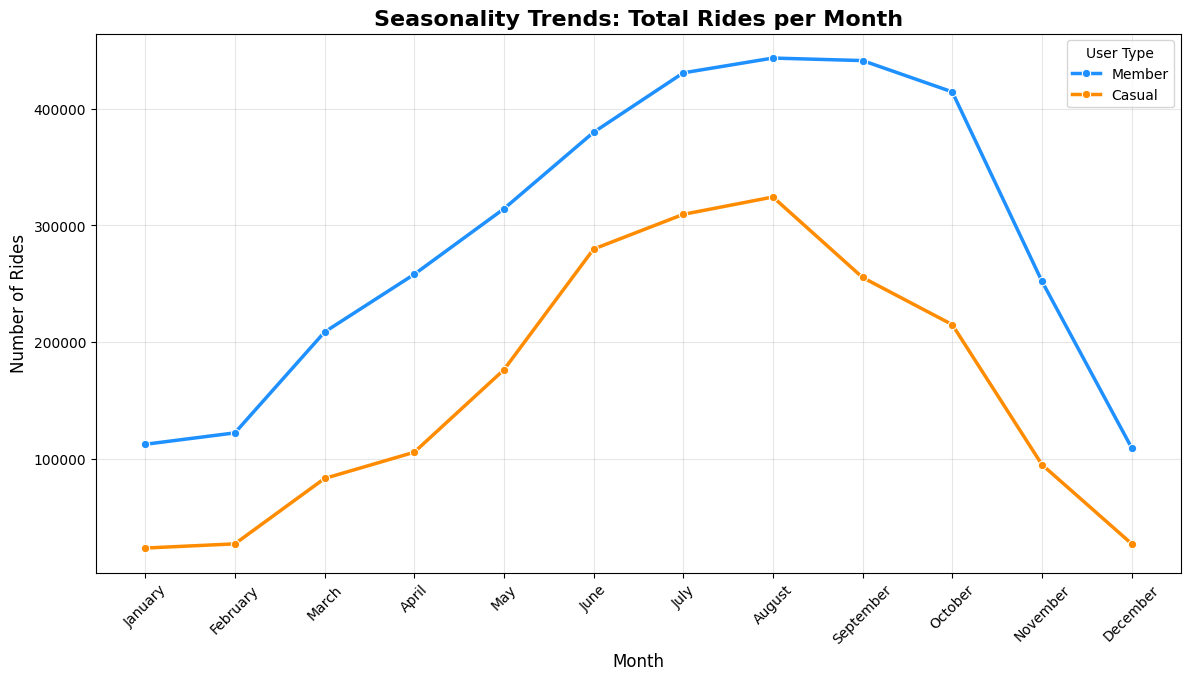

In [ ]:
# ----------------------------------------------------------------------------
# 6. [B] Seasonality Trends: Month-over-Month Analysis
# ----------------------------------------------------------------------------

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
               
month_col = 'month_name' if 'month_name' in df_monthly.columns else 'ride_month'

df_monthly[month_col] = pd.Categorical(df_monthly[month_col], categories=month_order, ordered=True)
df_monthly = df_monthly.sort_values(month_col)

plt.figure(figsize=(14, 7))

sns.lineplot(x=month_col, y='total_rides_per_month', hue='member_casual', 
             data=df_monthly, marker='o', linewidth=2.5, palette=['#1E90FF', '#FF8C00'])

plt.title('Seasonality Trends: Total Rides per Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(True, alpha=0.3)
plt.legend(title='User Type')

plt.show()


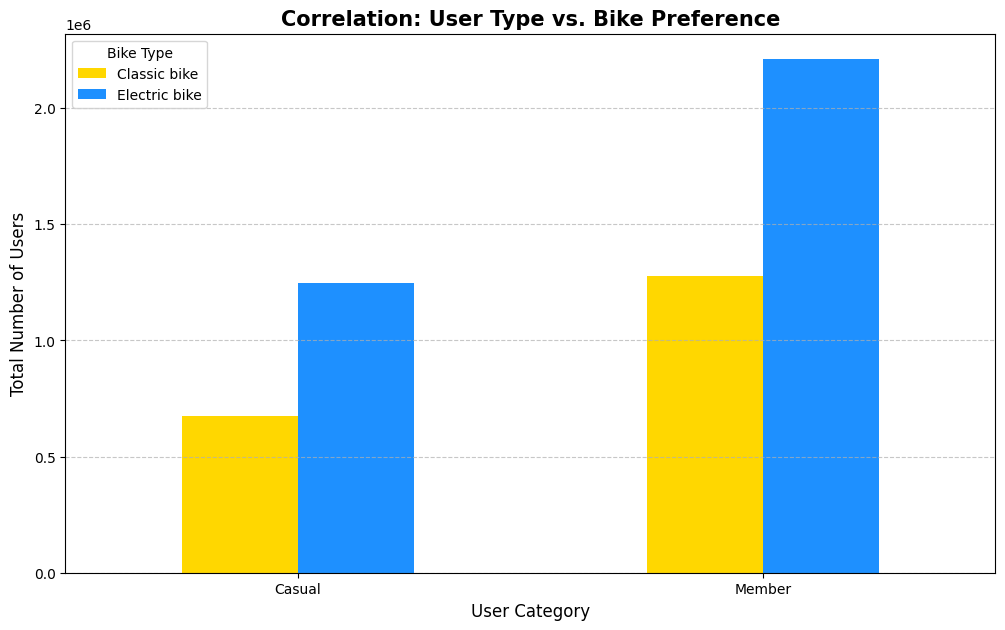

In [ ]:
df_bikes.columns = df_bikes.columns.str.strip()

correlation_data = df_bikes.groupby(['member_casual', 'rideable_type'])['number_of_bike_users'].sum().unstack()

plt.figure(figsize=(12, 7))
correlation_data.plot(kind='bar', stacked=False, ax=plt.gca(), color=['#FFD700', '#1E90FF', '#32CD32'])

plt.title('Correlation: User Type vs. Bike Preference', fontsize=15, fontweight='bold')
plt.xlabel('User Category', fontsize=12)
plt.ylabel('Total Number of Users', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Bike Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [26]:
df_bikes.to_csv('df_bikes.csv', index=False)
df_hourly.to_csv('df_hourly.csv',index=False)
df_metrics.to_csv('df_metrics.csv',index=False)
df_monthly.to_csv('df_monthly.csv',index=False)
df_proportions.to_csv('df_proportions.csv',index=False)
df_weekly.to_csv('df_weekly.csv',index=False)
df_stations.to_csv('df_stations.csv',index=False)
